# Detecção de Anomalias em Gastos Municipais do Paraná

Pipeline de 6 passos sobre os 399 municípios do PR (2020–2025), usando
**Despesas por Função** (DCA-Anexo I-E) do SICONFI e estimativas de
população do IBGE (SIDRA tab. 6579).

| Passo | O que faz |
|---|---|
| 1 | Imports |
| 2 | Carregar FINBRA (6 anos) + IBGE → painel município-ano |
| 3 | Limpar declarações ruins |
| 4 | **Criar features** (per capita, proporção, variação) |
| 5 | Normalizar (RobustScaler) |
| 6 | **Detectar** (Isolation Forest + LOF) |
| 7 | **Ranking + descrição das anomalias** |
| 8 | Exportar |



## 1 — Imports



In [107]:
import warnings, re, hashlib
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

DATA_DIR    = Path('data')
EXPORTS_DIR = Path('exports')
EXPORTS_DIR.mkdir(exist_ok=True)

ANOS = [2020, 2021, 2022, 2023, 2024, 2025]
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Funcoes de despesa: codigo -> nome
FUNCOES = {
    '01':'legislativa','02':'judiciaria','03':'essencial_justica','04':'administracao',
    '05':'defesa_nacional','06':'seguranca_publica','07':'relacoes_exteriores',
    '08':'assistencia_social','09':'previdencia_social','10':'saude','11':'trabalho',
    '12':'educacao','13':'cultura','14':'direitos_cidadania','15':'urbanismo',
    '16':'habitacao','17':'saneamento','18':'gestao_ambiental','19':'ciencia_tecnologia',
    '20':'agricultura','21':'organizacao_agraria','22':'industria','23':'comercio_servicos',
    '24':'comunicacoes','25':'energia','26':'transporte','27':'desporto_lazer',
    '28':'encargos_especiais','99':'reserva_contingencia',
}
COL_FUNCOES = list(FUNCOES.values())

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150

print('Setup ok.')



Setup ok.


## 2 — Carregamento

Lê 6 CSVs FINBRA (formato long, separador `;`, encoding latin-1, decimal
vírgula, 3 linhas de metadata no topo) e o CSV do IBGE (estimativas de
população por município). O resultado é um painel `município-ano`
com 29 colunas de função + população.



In [108]:
RE_TOP = re.compile(r'^\s*(\d{2})\s*-\s*(.+)$')
RE_SUB = re.compile(r'^\s*\d{2}\.\d{3}')


def _parse_valor_br(s):
    return pd.to_numeric(
        s.astype(str).str.strip()
         .str.replace('.', '', regex=False)
         .str.replace(',', '.', regex=False),
        errors='coerce')


def carregar_finbra(path, ano):
    df = None
    for enc in ['latin-1', 'cp1252', 'utf-8-sig', 'utf-8']:
        try:
            df = pd.read_csv(path, sep=';', encoding=enc, skiprows=3,
                             dtype=str, engine='python')
            df.columns = [str(c).strip().lstrip('\ufeff') for c in df.columns]
            if {'Cod.IBGE', 'Conta', 'Valor'}.issubset(set(df.columns)):
                break
        except Exception:
            df = None
    if df is None:
        raise RuntimeError(f'Nao consegui ler {path}')

    # filtros
    df = df[df['Coluna'].astype(str).str.strip() == 'Despesas Empenhadas'].copy()
    df['Conta'] = df['Conta'].astype(str).str.strip()
    df = df[~df['Conta'].str.contains('Exceto', case=False, na=False)]
    df = df[~df['Conta'].str.match(RE_SUB)]
    m = df['Conta'].str.extract(RE_TOP)
    df['cod_funcao'] = m[0]
    df = df[df['cod_funcao'].notna() & df['cod_funcao'].isin(FUNCOES.keys())]
    df['nome_funcao'] = df['cod_funcao'].map(FUNCOES)
    df['Valor'] = _parse_valor_br(df['Valor'])
    df = df.dropna(subset=['Valor'])
    df['Cod.IBGE'] = (df['Cod.IBGE'].astype(str).str.strip()
                       .str.replace('.', '', regex=False))
    df = df[df['Cod.IBGE'].str.fullmatch(r'41\d{5}')]
    df['cod_ibge'] = df['Cod.IBGE'].astype(int)
    df['municipio'] = (df['Instituição'].astype(str).str.strip()
                       .str.replace(r'\s*-\s*PR\s*$', '', regex=True)
                       .str.replace(r'^Prefeitura Municipal de\s+', '', regex=True))
    df['ano'] = ano
    return df[['cod_ibge', 'municipio', 'ano', 'nome_funcao', 'Valor']]


# Detectar arquivos duplicados
hashes = {}
for ano in ANOS:
    p = DATA_DIR / f'finbra_dca_ie_PR_{ano}.csv'
    if p.exists():
        h = hashlib.md5(p.read_bytes()).hexdigest()
        if h in hashes:
            print(f'  [AVISO] {p.name} e identico a {hashes[h]} — refazer download')
        hashes[h] = p.name

# Carregar
partes = []
for ano in ANOS:
    p = DATA_DIR / f'finbra_dca_ie_PR_{ano}.csv'
    if not p.exists():
        print(f'  [skip] {p.name} nao existe')
        continue
    d = carregar_finbra(p, ano)
    partes.append(d)
    print(f'  {p.name}: {len(d):,} linhas · {d["cod_ibge"].nunique()} municipios')

finbra = pd.concat(partes, ignore_index=True)
print(f'\nTotal: {len(finbra):,} linhas · {finbra["cod_ibge"].nunique()} municipios')



  finbra_dca_ie_PR_2020.csv: 5,965 linhas · 399 municipios
  finbra_dca_ie_PR_2021.csv: 5,975 linhas · 399 municipios
  finbra_dca_ie_PR_2022.csv: 6,120 linhas · 398 municipios
  finbra_dca_ie_PR_2023.csv: 6,163 linhas · 398 municipios
  finbra_dca_ie_PR_2024.csv: 6,173 linhas · 396 municipios
  finbra_dca_ie_PR_2025.csv: 3,757 linhas · 241 municipios

Total: 34,153 linhas · 399 municipios


In [109]:
def carregar_ibge(path):
    df = None
    for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
        try:
            tmp = pd.read_csv(path, sep=';', encoding=enc, skiprows=3,
                              dtype=str, engine='python')
            tmp.columns = [str(c).strip().lstrip('\ufeff') for c in tmp.columns]
            if any(re.fullmatch(r'\d{4}', c) for c in tmp.columns):
                df = tmp; break
        except Exception:
            continue
    if df is None:
        raise RuntimeError(f'Nao consegui ler {path}')

    mun_col  = df.columns[0]
    ano_cols = [c for c in df.columns if re.fullmatch(r'\d{4}', c)]
    df = df[[mun_col] + ano_cols].rename(columns={mun_col: 'municipio_ibge'})
    df = df.dropna(subset=['municipio_ibge'])
    df = df[df['municipio_ibge'].str.contains(r'\(PR\)$', regex=True)]
    df['municipio_ibge'] = df['municipio_ibge'].str.replace(
        r'\s*\(PR\)\s*$', '', regex=True).str.strip()

    pop = df.melt(id_vars='municipio_ibge', value_vars=ano_cols,
                  var_name='ano', value_name='populacao')
    pop['ano'] = pop['ano'].astype(int)
    pop['populacao'] = pd.to_numeric(
        pop['populacao'].astype(str).str.replace('.', '', regex=False),
        errors='coerce')
    pop = pop.dropna(subset=['populacao'])
    pop['populacao'] = pop['populacao'].astype(int)
    return pop


pop_ibge = carregar_ibge(DATA_DIR / 'populacao_ibge.csv')
print(f'IBGE: {len(pop_ibge):,} linhas · '
      f'{pop_ibge["municipio_ibge"].nunique()} municipios · '
      f'anos: {sorted(pop_ibge["ano"].unique())}')



IBGE: 1,596 linhas · 399 municipios · anos: [np.int64(2020), np.int64(2021), np.int64(2024), np.int64(2025)]


In [110]:
# Pivotar FINBRA: long -> wide (1 linha por municipio-ano)
agg = (finbra.groupby(['cod_ibge', 'municipio', 'ano', 'nome_funcao'])['Valor']
             .sum().reset_index())
wide = (agg.pivot_table(index=['cod_ibge', 'municipio', 'ano'],
                        columns='nome_funcao', values='Valor', fill_value=0.0)
          .reset_index())
wide.columns.name = None
for f in COL_FUNCOES:
    if f not in wide.columns:
        wide[f] = 0.0
wide = wide[['cod_ibge', 'municipio', 'ano'] + COL_FUNCOES]
wide['total_despesas'] = wide[COL_FUNCOES].sum(axis=1)

# Join com populacao por nome normalizado
def norm(s):
    return (s.astype(str).str.lower()
             .str.normalize('NFKD').str.encode('ascii', 'ignore').str.decode('ascii')
             .str.strip().str.replace(r'\s+', ' ', regex=True))

wide['_k']     = norm(wide['municipio'])
pop_ibge['_k'] = norm(pop_ibge['municipio_ibge'])
cod_map = wide.groupby('_k')['cod_ibge'].first().to_dict()
pop_ibge['cod_ibge'] = pop_ibge['_k'].map(cod_map)
pop_ibge = pop_ibge.dropna(subset=['cod_ibge']).copy()
pop_ibge['cod_ibge'] = pop_ibge['cod_ibge'].astype(int)

# Interpolar 2022/2023 (IBGE nao publicou) entre 2021 e 2024
idx = pd.MultiIndex.from_product([pop_ibge['cod_ibge'].unique(), ANOS],
                                  names=['cod_ibge', 'ano'])
pop_full = (pop_ibge[['cod_ibge', 'ano', 'populacao']]
            .set_index(['cod_ibge', 'ano']).reindex(idx).reset_index()
            .sort_values(['cod_ibge', 'ano']))
pop_full['populacao'] = (pop_full.groupby('cod_ibge')['populacao']
                          .transform(lambda s: s.interpolate(method='linear',
                                                             limit_direction='both')))
pop_full['populacao'] = pop_full['populacao'].round().astype('Int64')

raw_df = wide.drop(columns='_k').merge(pop_full, on=['cod_ibge', 'ano'], how='left')
raw_df = raw_df.dropna(subset=['populacao']).copy()
raw_df['populacao'] = raw_df['populacao'].astype(int)

print(f'Painel municipio-ano: {raw_df.shape}')
print(f'\nCobertura por ano:')
print(raw_df.groupby('ano').size().rename('n').to_string())



Painel municipio-ano: (2231, 34)

Cobertura por ano:
ano
2020    399
2021    399
2022    398
2023    398
2024    396
2025    241


## 3 — Limpeza

Remove linhas com declaração extremamente incompleta (< 3 funções com
valor) — provável erro de declaração, não anomalia real de gasto. Mantém
flag de valores negativos (devoluções de verba).



In [111]:
df = raw_df.copy()
n_decl = (df[COL_FUNCOES] > 0).sum(axis=1)
df['n_funcoes_declaradas'] = n_decl
df['flag_negativo'] = (df[COL_FUNCOES] < 0).any(axis=1)

df = df[n_decl >= 3].copy()
df = df[df['total_despesas'] > 0].reset_index(drop=True)
print(f'Apos limpeza: {len(df):,} linhas · {df["cod_ibge"].nunique()} municipios')



Apos limpeza: 2,226 linhas · 399 municipios


## 4 — Features

Três famílias de variáveis. Cada uma responde a uma pergunta diferente
sobre "como o município gastou":

**Per capita** (`*_pc`) — *gastou muito ou pouco?*
> `saude_pc = saude / populacao`. Se a média do estado é R$ 1.200/hab e
> esse município gastou R$ 5.000/hab, está alto.

**Proporção** (`*_prop`) — *distribuiu como?*
> `saude_prop = saude / total`. Captura **perfil** de gasto. Município
> que gasta 70% em administração e 5% em saúde tem perfil atípico
> mesmo se o total estiver normal.

**Variação ano-a-ano** (`*_var`) — *mudou bruscamente?*
> Diferença percentual contra o ano anterior. Município que dobra o
> gasto em saúde de um ano pro outro chama atenção.

Mais 2 variáveis de contexto: `log_pop` (porte da cidade) e `hhi`
(concentração — alto = poucas funções dominam o gasto).



In [112]:
df = df.sort_values(['cod_ibge', 'ano']).reset_index(drop=True)

# Per capita
PC_COLS = []
for f in COL_FUNCOES:
    c = f + '_pc'
    df[c] = df[f] / df['populacao'].clip(lower=1)
    PC_COLS.append(c)

# Proporcao
PROP_COLS = []
tot = df['total_despesas'].clip(lower=1)
for f in COL_FUNCOES:
    c = f + '_prop'
    df[c] = df[f] / tot
    PROP_COLS.append(c)

# Variacao ano-a-ano em funcoes-chave
FUNC_KEY = ['saude', 'educacao', 'administracao', 'urbanismo',
            'assistencia_social', 'transporte']
VAR_COLS = []
for f in FUNC_KEY:
    pc = f + '_pc'
    var = (df[pc] - df.groupby('cod_ibge')[pc].shift(1)) / \
          df.groupby('cod_ibge')[pc].shift(1).replace(0, np.nan)
    df[f + '_var'] = var.clip(-5, 5).fillna(0.0)
    VAR_COLS.append(f + '_var')

# Contexto
df['log_pop']  = np.log1p(df['populacao'])
df['hhi']      = (df[PROP_COLS] ** 2).sum(axis=1)
CTX_COLS = ['log_pop', 'hhi']

FEATURES = PC_COLS + PROP_COLS + VAR_COLS + CTX_COLS
print(f'Total de features: {len(FEATURES)}')
print(f'  per_capita: {len(PC_COLS)}')
print(f'  proporcao:  {len(PROP_COLS)}')
print(f'  variacao:   {len(VAR_COLS)}')
print(f'  contexto:   {len(CTX_COLS)}')



Total de features: 66
  per_capita: 29
  proporcao:  29
  variacao:   6
  contexto:   2


## 5 — Normalização

`RobustScaler` (centra na mediana, escala pelo IQR). Usamos *robust* em
vez de *standard* porque o objetivo é **detectar** outliers — se a
normalização usar média e desvio-padrão, ela mesma é puxada pelos
outliers e os esconde.



In [113]:
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(df[FEATURES])
scaler = RobustScaler()
X = scaler.fit_transform(X_imp)
print(f'X: {X.shape}  (mediana={np.median(X):.3f}, IQR≈{np.percentile(X,75)-np.percentile(X,25):.3f})')



X: (2226, 66)  (mediana=0.000, IQR≈0.361)


## 6 — Detecção: Isolation Forest + LOF

**Isolation Forest** (Liu 2008): constrói árvores aleatórias que dividem
o espaço; pontos anômalos ficam isolados em poucas divisões. Bom para
anomalias **globais** (ponto longe de todos).

**Local Outlier Factor** (Breunig 2000): compara a densidade ao redor
de um ponto com a densidade ao redor dos vizinhos. Pega anomalias
**locais** (ponto isolado dentro do seu grupo).

Os dois cobrem casos diferentes; combinamos:

```
score = 0.6 × IF + 0.4 × LOF
```

IF tem peso maior porque estamos em alta dimensão (74 features), regime
em que LOF fica ruidoso.

**Classificação:** P95 → `Critica` (top 5%); P80 → `Suspeita` (top 20%);
resto → `Regular`.



In [114]:
# Isolation Forest
iso = IsolationForest(n_estimators=300, contamination='auto',
                      random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X)
if_raw = -iso.score_samples(X)
if_norm = (if_raw - if_raw.min()) / (if_raw.max() - if_raw.min())

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto', n_jobs=-1)
lof.fit_predict(X)
lof_raw = -lof.negative_outlier_factor_
lof_norm = (lof_raw - lof_raw.min()) / (lof_raw.max() - lof_raw.min())

# Ensemble
df['score_if']  = if_norm
df['score_lof'] = lof_norm
df['score']     = 0.6 * if_norm + 0.4 * lof_norm

p95 = df['score'].quantile(0.95)
p80 = df['score'].quantile(0.80)
df['classe'] = np.where(df['score'] >= p95, 'Critica',
                np.where(df['score'] >= p80, 'Suspeita', 'Regular'))

print(f'Cortes: P80 = {p80:.3f} · P95 = {p95:.3f}')
print(df['classe'].value_counts().to_string())



Cortes: P80 = 0.211 · P95 = 0.352
classe
Regular     1780
Suspeita     334
Critica      112


## 7 — Ranking e descrição das anomalias

Para cada anomalia crítica, comparamos com 20 municípios não-flagados de
população mais próxima no mesmo ano (centróide de pares). Reportamos:
- valores absolutos (total per capita, % saúde, % educação)
- top 3 funções gastando **acima** dos pares
- top 3 funções gastando **abaixo** dos pares



In [115]:
def descrever(idx, n_pares=20):
    row = df.loc[idx]

    # Pares: mesmo ano, populacao proxima, nao-flagados
    pool = df[(df['ano'] == row['ano']) & (df['classe'] == 'Regular') &
              (df.index != idx)].copy()
    pool['_d'] = (pool['populacao'] - row['populacao']).abs()
    pares = pool.nsmallest(n_pares, '_d')

    pc = [f + '_pc' for f in COL_FUNCOES]
    cent = pares[pc].mean()
    desv = {}
    for f, c, v in zip(COL_FUNCOES, cent.values, row[pc].values):
        if c > 0:
            desv[f] = (v - c) / c * 100

    acima = sorted([(f, d) for f, d in desv.items() if d > 50],
                   key=lambda x: -x[1])[:3]
    abaixo = sorted([(f, d) for f, d in desv.items() if d < -50],
                    key=lambda x: x[1])[:3]
    return acima, abaixo


def imprimir(idx, rank):
    row = df.loc[idx]
    acima, abaixo = descrever(idx)
    med_pc = df['total_pc' if 'total_pc' in df.columns else 'total_despesas'].median()
    if 'total_pc' not in df.columns:
        df['total_pc'] = df['total_despesas'] / df['populacao']
        med_pc = df['total_pc'].median()

    razao = row['total_pc'] / med_pc

    print(f'\n#{rank:>2}  {row["municipio"]} ({row["ano"]})'
          f'    score {row["score"]:.3f}    [{row["classe"]}]')
    print(f'      {row["populacao"]:>7,} hab  ·  '
          f'gasto total R$ {row["total_despesas"]/1e6:,.1f}M  ·  '
          f'R$ {row["total_pc"]:,.0f}/hab ({razao:.1f}x mediana PR)')
    print(f'      saude: {row["saude_prop"]*100:5.1f}% '
          f'(min 15%)  ·  educacao: {row["educacao_prop"]*100:5.1f}% (min 25%)')

    if acima:
        print(f'      Acima dos pares:')
        for f, d in acima:
            print(f'        + {f:22s} R$ {row[f+"_pc"]:>9,.0f}/hab  ({d:+.0f}%)')
    if abaixo:
        print(f'      Abaixo dos pares:')
        for f, d in abaixo:
            print(f'        - {f:22s} R$ {row[f+"_pc"]:>9,.0f}/hab  ({d:+.0f}%)')


df['total_pc'] = df['total_despesas'] / df['populacao']

top20 = df[df['classe'] == 'Critica'].nlargest(20, 'score')
print('TOP 20 ANOMALIAS')
print('=' * 78)
for r, idx in enumerate(top20.index, 1):
    imprimir(idx, r)



TOP 20 ANOMALIAS

# 1  Salgado Filho (2025)    score 0.733    [Critica]
        4,090 hab  ·  gasto total R$ 48.0M  ·  R$ 11,741/hab (2.0x mediana PR)
      saude:  20.5% (min 15%)  ·  educacao:  20.2% (min 25%)
      Acima dos pares:
        + defesa_nacional        R$       495/hab  (+115757%)
        + industria              R$        71/hab  (+391%)
        + transporte             R$     1,884/hab  (+207%)
      Abaixo dos pares:
        - judiciaria             R$         0/hab  (-100%)
        - essencial_justica      R$         0/hab  (-100%)
        - seguranca_publica      R$         0/hab  (-100%)

# 2  Itaipulândia (2025)    score 0.710    [Critica]
       12,116 hab  ·  gasto total R$ 250.4M  ·  R$ 20,669/hab (3.5x mediana PR)
      saude:  19.7% (min 15%)  ·  educacao:  22.1% (min 25%)
      Acima dos pares:
        + energia                R$       691/hab  (+5371%)
        + comercio_servicos      R$       657/hab  (+1829%)
        + industria              R$       441/

### Gráfico do ranking



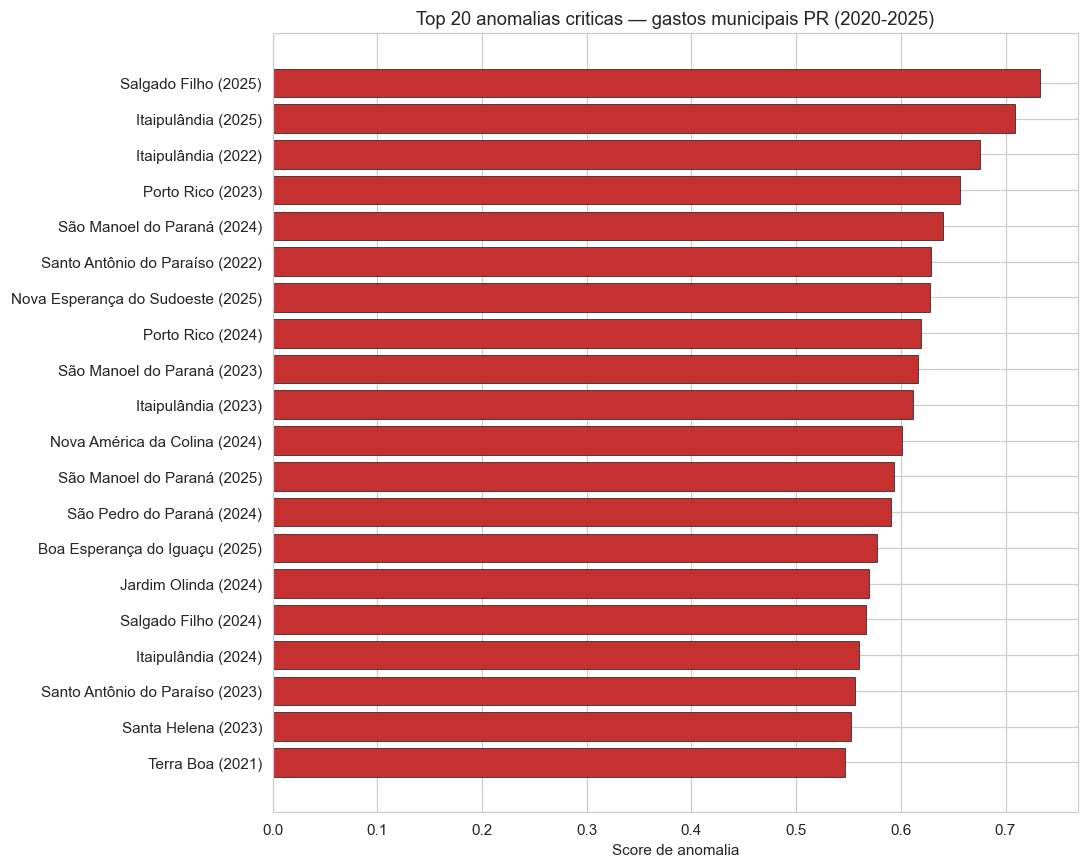

In [116]:
fig, ax = plt.subplots(figsize=(10, 8))
labels = [f'{m} ({a})' for m, a in zip(top20['municipio'], top20['ano'])]
ax.barh(range(len(top20)), top20['score'].values,
        color='#c53030', edgecolor='black', linewidth=0.4)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Score de anomalia')
ax.set_title('Top 20 anomalias criticas — gastos municipais PR (2020-2025)')
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_ranking.png', bbox_inches='tight')
plt.show()



## 8 — Exportação



In [117]:
out_cols = (
    ['cod_ibge', 'municipio', 'ano', 'populacao', 'total_despesas', 'total_pc']
    + ['saude', 'educacao', 'administracao']
    + ['saude_prop', 'educacao_prop', 'hhi']
    + ['n_funcoes_declaradas', 'flag_negativo']
    + ['score_if', 'score_lof', 'score', 'classe']
)
out_cols = [c for c in out_cols if c in df.columns]

df[out_cols].to_csv(EXPORTS_DIR / 'gastos_com_score.csv', index=False)
df[df['classe'] != 'Regular'][out_cols] \
  .sort_values('score', ascending=False) \
  .to_csv(EXPORTS_DIR / 'gastos_anomalias.csv', index=False)

print(f'gastos_com_score.csv : {len(df):,} linhas')
print(f'gastos_anomalias.csv : {(df["classe"] != "Regular").sum():,} linhas')
print(f'fig_ranking.png      : ranking das 20 maiores anomalias')

n_crit = (df['classe'] == 'Critica').sum()
n_susp = (df['classe'] == 'Suspeita').sum()
print(f'\nResumo: {n_crit} criticas + {n_susp} suspeitas em {len(df):,} municipio-ano')



gastos_com_score.csv : 2,226 linhas
gastos_anomalias.csv : 446 linhas
fig_ranking.png      : ranking das 20 maiores anomalias

Resumo: 112 criticas + 334 suspeitas em 2,226 municipio-ano
